In [1]:
#从零开始构建批量归一化
import torch
from torch import nn
from d2l import torch as d2l


def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # 通过is_grad_enabled来判断当前模式是训练模式还是预测模式
    if not torch.is_grad_enabled():
        # 如果是在预测模式下，直接使用传入的移动平均所得的均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # 使用全连接层的情况，计算特征维上的均值和方差
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # 使用二维卷积层的情况，计算通道维上（axis=1）的均值和方差。
            # 这里我们需要保持X的形状以便后面可以做广播运算
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # 训练模式下，用当前的均值和方差做标准化
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # 更新移动平均的均值和方差
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta  # 缩放和移位
    return Y, moving_mean.data, moving_var.data

In [2]:
#创建正确的BatchNorm图层
class BacthNorm(nn.Module):
    def __init__(self,num_features,num_dims):
        super().__init__()
        if num_dims==2:
            shape=(1,num_features)
        else:
            shape=(1,num_features,1,1)
        self.gamma=nn.Parameter(torch.ones(shape))
        self.beta=nn.Parameter(torch.zeros(shape))
        self.moving_mean=torch.zeros(shape)
        self.moving_var=torch.ones(shape)

    def forward(self,X):
        if self.moving_mean.device != X.device:
            self.moving_mean=self.moving_mean.to(X.device)
            self.moving_var=self.moving_var.to(X.device)
        Y,self.moving_mean,self.moving_var=batch_norm(
            X,self.gamma,self.beta,self.moving_mean,self.moving_var,eps=1e-5,momentum=0.9
        )
        return Y 

In [3]:
#将其应用于LeNet模型
net=nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5,padding=2),BacthNorm(6,num_dims=4),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),
    nn.Conv2d(6,16,kernel_size=5),BacthNorm(16,num_dims=4),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),nn.Flatten(),
    nn.Linear(16*5*5,120),BacthNorm(120,num_dims=2),nn.Sigmoid(),
    nn.Linear(120,84),BacthNorm(84,num_dims=2),nn.Sigmoid(),
    nn.Linear(84,10)
)

loss 0.247, train acc 0.909, test acc 0.859
64535.6 examples/sec on cuda:0


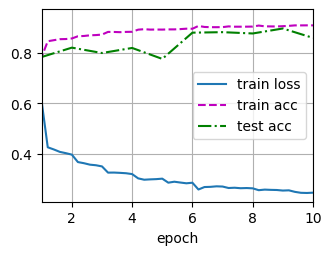

In [12]:
#测试
lr,num_epochs,batch_size=0.5,10,256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())

In [10]:
#将其应用于LeNet模型,简洁实现调用nn.BatchNorm2d()
net=nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5,padding=2),nn.BatchNorm2d(6),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),
    nn.Conv2d(6,16,kernel_size=5),nn.BatchNorm2d(16),nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2,stride=2),nn.Flatten(),
    nn.Linear(16*5*5,120),nn.BatchNorm1d(120),nn.Sigmoid(),
    nn.Linear(120,84),nn.BatchNorm1d(84),nn.Sigmoid(),
    nn.Linear(84,10)
)

loss 0.247, train acc 0.908, test acc 0.879
63947.1 examples/sec on cuda:0


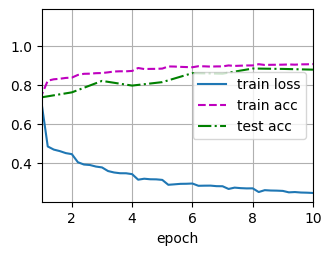

In [11]:
d2l.train_ch6(net,train_iter,test_iter,num_epochs,lr,d2l.try_gpu())